# Notebook 2: Groundedness grading with Azure OpenAI

This notebook loads the synthetic groundedness QnA dataset built in Notebook 1 and evaluates multiple Azure OpenAI deployments as graders using three prompt templates. It also compares the model-based graders against Azure AI Evaluation's `GroundednessEvaluator`, explores stochasticity via multiple runs, and is ready to log results to an Azure AI Foundry project.


In [2]:
import os
import json
from typing import List, Dict, Callable

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from azure.ai.evaluation import GroundednessEvaluator, evaluate

# Azure OpenAI configuration (environment variables should already be set)
from azure.identity import DefaultAzureCredential
import requests

In [3]:
# Acquire Azure AD (Entra ID) token
credential = DefaultAzureCredential()
AZURE_AI_PROJECT_URL = "https://evalsharedfoundry.openai.azure.com/"

token = credential.get_token(f"https://cognitiveservices.azure.com/.default").token
openai_base_url = AZURE_AI_PROJECT_URL + "openai/v1/"

# GPT-5 uses a different endpoint and client
from azure.identity import get_bearer_token_provider
from openai import AzureOpenAI

GPT5_ENDPOINT = "https://evalsharedfoundry.cognitiveservices.azure.com/"
GPT5_API_VERSION = "2024-12-01-preview"
token_provider = get_bearer_token_provider(DefaultAzureCredential(), "https://cognitiveservices.azure.com/.default")

gpt5_client = AzureOpenAI(
    api_version=GPT5_API_VERSION,
    azure_endpoint=GPT5_ENDPOINT,
    azure_ad_token_provider=token_provider,
)

MODEL_DEPLOYMENTS = [
    {"name": "gpt-4.1-eval", "deployment": "gpt-4.1", "use_gpt5_client": False},
    {"name": "gpt-5-eval", "deployment": "gpt-5", "use_gpt5_client": True},
    {"name": "gpt-4o-mini-eval", "deployment": "gpt-4o-mini", "use_gpt5_client": True},
]

N_RUNS_PER_QUESTION = 5  # number of stochastic runs per question / template / model

In [4]:
def call_openai_chat(deployment_id, messages, max_tokens=100):
    url = f"{AZURE_AI_PROJECT_URL}openai/deployments/{deployment_id}/chat/completions?api-version=2024-02-15-preview"
    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json",
    }
    payload = {
        "messages": messages,
        "max_tokens": max_tokens,
    }
    response = requests.post(url, headers=headers, json=payload)
    response.raise_for_status()
    return response.json()["choices"][0]["message"]["content"].strip()

In [5]:
DATA_PATH = "data/synthetic_groundedness_qna.jsonl"
with open(DATA_PATH, "r", encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

df = pd.DataFrame(records)


def classification_metrics(y_true, y_pred):
    """
    Compute simple metrics for ordinal 1-5 predictions:
    - exact label match
    - within-1 accuracy
    - Pearson correlation
    - Spearman correlation
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    exact = (y_true == y_pred).mean()
    within_1 = (np.abs(y_true - y_pred) <= 1).mean()
    pearson = pearsonr(y_true, y_pred)[0]
    spearman = spearmanr(y_true, y_pred)[0]
    return {
        "exact_match": float(exact),
        "within_1": float(within_1),
        "pearson": float(pearson),
        "spearman": float(spearman),
    }

# Uncomment to inspect the dataset distribution
# display(df.head())
# display(df["ground_truth_score"].value_counts())


In [6]:
RUBRIC_FOR_PROMPTS_NUMERIC = {
    1: "Severely ungrounded or contradictory - mostly unrelated to the context or clearly conflicts with it.",
    2: "Largely ungrounded - only superficial overlap with the context; most claims can't be verified from the context.",
    3: "Mixed - some important claims are supported by the context, others are not clearly supported.",
    4: "Mostly grounded - the main answer is supported by the context, with only minor extra elaboration.",
    5: "Fully grounded - all important claims can be directly supported by the context; no speculative additions.",
}

RUBRIC_FOR_PROMPTS_ALPHA = {
    "E": "Severely ungrounded or contradictory.",
    "D": "Largely ungrounded - only superficial overlap with the context; most claims are unsupported.",
    "C": "Mixed - some important claims are supported, others are not clearly supported.",
    "B": "Mostly grounded - the main answer is supported by the context, with only minor extra elaboration.",
    "A": "Fully grounded - all important claims are clearly supported by the context.",
}

LABEL_TO_SCORE = {"A": 5, "B": 4, "C": 3, "D": 2, "E": 1}


In [8]:
def build_system_and_user_messages(template_id: str, row: Dict):
    question = row["question"]
    context = row["context"]
    answer = row["answer"]

    if template_id == "numeric_free":
        system_text = """You are an expert evaluator of answer groundedness.
Given a question, a retrieved context, and an answer, rate how well the answer is grounded
in the context on a scale from 1 (not grounded) to 5 (fully grounded).
Grounded answers base their claims on the context; ungrounded answers invent facts or contradict the context.
Only output the integer 1, 2, 3, 4, or 5 with no extra text."""
    elif template_id == "numeric_rubric":
        system_text = """You are an expert judge of how well answers are grounded in a given context.
Use the following 1–5 groundedness scale:

1: Severely ungrounded or contradictory - mostly unrelated to the context or clearly conflicts with it.
2: Largely ungrounded - only superficial overlap with the context; most claims can't be verified from the context.
3: Mixed - some important claims are supported by the context, others are not clearly supported.
4: Mostly grounded - the main answer is supported by the context, with only minor extra elaboration.
5: Fully grounded - all important claims can be directly supported by the context; no speculative additions.

Return only a single integer 1, 2, 3, 4, or 5."""
    elif template_id == "alpha_rubric":
        system_text = """You are an expert judge of how well answers are grounded in a given context.
Use the following labels:

A: Fully grounded - all important claims are clearly supported by the context.
B: Mostly grounded - the main answer is supported by the context, with only minor extra elaboration.
C: Mixed - some important claims are supported, others are not clearly supported.
D: Largely ungrounded - only superficial overlap with the context; most claims are unsupported.
E: Severely ungrounded or contradictory - content is unrelated to or in conflict with the context.

Choose exactly one label (A, B, C, D, or E) and output just that single letter."""
    else:
        raise ValueError(f"Unknown template_id: {template_id}")

    if template_id == "alpha_rubric":
        final_prompt_line = "Groundedness label (A-E):"
    else:
        final_prompt_line = "Groundedness score (1-5):"

    user_text = f"""Question:
{question}

Retrieved context:
{context}

Answer:
{answer}

{final_prompt_line}
"""
    return system_text, user_text


def grade_once_with_template(
    deployment: str,
    template_id: str,
    row: Dict,
) -> float:
    """Call a given Azure OpenAI deployment with a grading template and return a numeric score 1-5."""
    system_text, user_text = build_system_and_user_messages(template_id, row)

    raw = call_openai_chat(
        deployment_id=deployment,
        messages=[
            {"role": "system", "content": system_text},
            {"role": "user", "content": user_text},
        ],
        max_tokens=4,
    )

    if template_id == "alpha_rubric":
        label = raw[0].upper() if raw else ""
        score = LABEL_TO_SCORE.get(label, np.nan)
    else:
        digits = "".join(ch for ch in raw if ch.isdigit())
        score = float(digits) if digits in {"1", "2", "3", "4", "5"} else np.nan

    return score


In [9]:
import asyncio
import aiohttp
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor

BATCH_SIZE = 10  # number of parallel requests

async def call_openai_chat_async(session, deployment_id, messages, max_tokens=100):
    """Async version of call_openai_chat for non-GPT5 models."""
    url = f"{AZURE_AI_PROJECT_URL}openai/deployments/{deployment_id}/chat/completions?api-version=2024-02-15-preview"
    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json",
    }
    payload = {
        "messages": messages,
        "max_tokens": max_tokens,
    }
    async with session.post(url, headers=headers, json=payload) as response:
        response.raise_for_status()
        data = await response.json()
        return data["choices"][0]["message"]["content"].strip()


def call_gpt5_sync(deployment_id, messages, max_tokens=1024):
    """
    Synchronous call for reasoning models (GPT-5, etc.) using the AzureOpenAI client.
    Reasoning models need larger max_completion_tokens for internal chain-of-thought.
    """
    response = gpt5_client.chat.completions.create(
        messages=messages,
        max_completion_tokens=max_tokens,  # Reasoning models need ~1000+ tokens
        model=deployment_id,
    )
    content = response.choices[0].message.content
    return content.strip() if content else ""


async def grade_once_async(session, semaphore, deployment, template_id, row, use_gpt5_client, executor):
    """Async version of grade_once_with_template with semaphore for rate limiting."""
    async with semaphore:
        system_text, user_text = build_system_and_user_messages(template_id, row)
        messages = [
            {"role": "system", "content": system_text},
            {"role": "user", "content": user_text},
        ]
        
        if use_gpt5_client:
            # Run GPT-5/reasoning model sync call in thread pool to avoid blocking
            loop = asyncio.get_event_loop()
            raw = await loop.run_in_executor(
                executor,
                call_gpt5_sync,
                deployment,
                messages,
                10240,  # Reasoning models need larger token budget
            )
        else:
            raw = await call_openai_chat_async(
                session,
                deployment_id=deployment,
                messages=messages,
                max_tokens=100,
            )
        
        if template_id == "alpha_rubric":
            label = raw[0].upper() if raw else ""
            score = LABEL_TO_SCORE.get(label, np.nan)
        else:
            digits = "".join(ch for ch in raw if ch.isdigit())
            score = float(digits) if digits in {"1", "2", "3", "4", "5"} else np.nan
        
        return score


async def run_all_evaluations():
    """Run all evaluations with batched parallelism."""
    templates = ["numeric_free", "numeric_rubric", "alpha_rubric"]
    
    # Build list of all evaluation tasks metadata
    task_params = []
    for model in MODEL_DEPLOYMENTS:
        for template_id in templates:
            for run_idx in range(N_RUNS_PER_QUESTION):
                for _, row in df.iterrows():
                    task_params.append({
                        "model": model,
                        "template_id": template_id,
                        "run_idx": run_idx,
                        "row": row.to_dict(),
                    })
    
    print(f"Total tasks: {len(task_params)}")
    
    # Create semaphore to limit concurrent requests
    semaphore = asyncio.Semaphore(BATCH_SIZE)
    
    # Thread pool for GPT-5 sync calls
    executor = ThreadPoolExecutor(max_workers=BATCH_SIZE)
    
    all_results = []
    
    # Configure connector with keep-alive and limits
    connector = aiohttp.TCPConnector(limit=BATCH_SIZE, keepalive_timeout=30)
    timeout = aiohttp.ClientTimeout(total=120)
    
    async with aiohttp.ClientSession(connector=connector, timeout=timeout) as session:
        # Process in batches for better progress tracking
        pbar = tqdm(total=len(task_params), desc="Evaluating")
        
        for i in range(0, len(task_params), BATCH_SIZE):
            batch = task_params[i:i + BATCH_SIZE]
            
            async def process_one(p):
                try:
                    score = await grade_once_async(
                        session,
                        semaphore,
                        p["model"]["deployment"],
                        p["template_id"],
                        p["row"],
                        p["model"]["use_gpt5_client"],
                        executor,
                    )
                except Exception as e:
                    print(f"Error ({p['model']['name']}): {e}")
                    score = np.nan
                
                return {
                    "id": p["row"]["id"],
                    "ground_truth_score": p["row"]["ground_truth_score"],
                    "model": p["model"]["name"],
                    "deployment": p["model"]["deployment"],
                    "template": p["template_id"],
                    "run": p["run_idx"],
                    "pred_score": score,
                }
            
            # Process current batch concurrently
            batch_tasks = [process_one(p) for p in batch]
            batch_results = await asyncio.gather(*batch_tasks, return_exceptions=True)
            
            # Handle any exceptions in results
            for result in batch_results:
                if isinstance(result, Exception):
                    print(f"Batch error: {result}")
                else:
                    all_results.append(result)
            
            pbar.update(len(batch))
        
        pbar.close()
    
    executor.shutdown(wait=False)
    return all_results

In [ ]:
# Run the async evaluation
all_preds = await run_all_evaluations()
preds_df = pd.DataFrame(all_preds)
print(f"Completed {len(preds_df)} evaluations")
preds_df.head()
# persistent storage of results
preds_df.to_csv("data/synthetic_groundedness_evaluation_results.csv", index=False)

In [16]:
# =============================================================================
# RESUME & FIX: Re-run any NaN rows with PARALLELIZATION
# =============================================================================
# GPT-5 is a reasoning model - needs ~1000+ tokens for internal reasoning.
# Other models (gpt-4o-mini) don't need as many tokens.
# This cell saves progress incrementally so it can be resumed if interrupted.

import asyncio
import aiohttp
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor

BATCH_SIZE = 20  # number of parallel requests
SAVE_EVERY = 100  # save progress every N completions

# Reasoning models need larger token budgets for chain-of-thought
REASONING_MODELS = {"gpt-5"}


async def grade_fix_async(session, semaphore, model_config, template_id, row_data, executor):
    """
    Async grading function for the fix/resume operation.
    Uses appropriate client based on model config.
    """
    async with semaphore:
        system_text, user_text = build_system_and_user_messages(template_id, row_data)
        messages = [
            {"role": "system", "content": system_text},
            {"role": "user", "content": user_text},
        ]
        
        try:
            if model_config["use_gpt5_client"]:
                # Determine token limit based on whether it's a reasoning model
                is_reasoning = model_config["deployment"] in REASONING_MODELS
                max_tokens = 1024 if is_reasoning else 100
                
                # Run sync call in thread pool
                loop = asyncio.get_event_loop()
                response = await loop.run_in_executor(
                    executor,
                    lambda mt=max_tokens: gpt5_client.chat.completions.create(
                        messages=messages,
                        max_completion_tokens=mt,
                        model=model_config["deployment"],
                    )
                )
                raw = response.choices[0].message.content
                raw = raw.strip() if raw else ""
            else:
                # Use REST API for standard models
                raw = await call_openai_chat_async(
                    session,
                    deployment_id=model_config["deployment"],
                    messages=messages,
                    max_tokens=10,
                )
            
            # Parse score
            if template_id == "alpha_rubric":
                label = raw[0].upper() if raw else ""
                score = LABEL_TO_SCORE.get(label, np.nan)
            else:
                digits = "".join(ch for ch in raw if ch.isdigit())
                score = float(digits) if digits in {"1", "2", "3", "4", "5"} else np.nan
            
            return score
            
        except Exception as e:
            print(f"Error ({model_config['name']}): {e}")
            return np.nan


async def run_fix_evaluations(rows_to_fix_df, model_config_lookup, df_lookup, results_df, save_path):
    """Run fix evaluations with batched parallelism and incremental saving."""
    
    # Build list of all fix tasks
    task_params = []
    for idx, row in rows_to_fix_df.iterrows():
        model_config = model_config_lookup.get(row["model"])
        if model_config is None:
            continue
        original_row = df_lookup.loc[row["id"]].to_dict()
        task_params.append({
            "idx": idx,
            "model_config": model_config,
            "template_id": row["template"],
            "row_data": original_row,
        })
    
    print(f"Tasks to process: {len(task_params)}")
    
    # Create semaphore to limit concurrent requests
    semaphore = asyncio.Semaphore(BATCH_SIZE)
    
    # Thread pool for sync calls
    executor = ThreadPoolExecutor(max_workers=BATCH_SIZE)
    
    completed = 0
    errors = 0
    
    # Configure connector
    connector = aiohttp.TCPConnector(limit=BATCH_SIZE, keepalive_timeout=30)
    timeout = aiohttp.ClientTimeout(total=180)  # 3 min timeout per request
    
    async with aiohttp.ClientSession(connector=connector, timeout=timeout) as session:
        pbar = tqdm(total=len(task_params), desc="Re-evaluating")
        
        for i in range(0, len(task_params), BATCH_SIZE):
            batch = task_params[i:i + BATCH_SIZE]
            
            async def process_one(p):
                score = await grade_fix_async(
                    session,
                    semaphore,
                    p["model_config"],
                    p["template_id"],
                    p["row_data"],
                    executor,
                )
                return {"idx": p["idx"], "pred_score": score}
            
            # Process current batch concurrently
            batch_tasks = [process_one(p) for p in batch]
            batch_results = await asyncio.gather(*batch_tasks, return_exceptions=True)
            
            # Handle results and update dataframe immediately
            for result in batch_results:
                if isinstance(result, Exception):
                    print(f"Batch error: {result}")
                    errors += 1
                else:
                    results_df.loc[result["idx"], "pred_score"] = result["pred_score"]
                    completed += 1
                    if np.isnan(result["pred_score"]):
                        errors += 1
            
            pbar.update(len(batch))
            
            # Incremental save
            if completed % SAVE_EVERY < BATCH_SIZE:
                results_df.to_csv(save_path, index=False)
        
        pbar.close()
    
    executor.shutdown(wait=False)
    
    # Final save
    results_df.to_csv(save_path, index=False)
    
    return completed, errors


# Load existing results
save_path = "data/synthetic_groundedness_evaluation_results.csv"
existing_preds_df = pd.read_csv(save_path)

# Check NaN counts before fix
print("=== NaN count per model BEFORE fix ===")
print(existing_preds_df.groupby("model")["pred_score"].apply(lambda x: x.isna().sum()))
print(f"\nTotal NaN rows: {existing_preds_df['pred_score'].isna().sum()}")

# Get ALL rows that need re-evaluation (NaN pred_score) - any model
nan_mask = existing_preds_df["pred_score"].isna()
rows_to_fix = existing_preds_df[nan_mask].copy()
print(f"\nRows to re-evaluate: {len(rows_to_fix)}")

if len(rows_to_fix) == 0:
    print("\nNo rows need fixing!")
    preds_df = existing_preds_df
else:
    # Create model config lookup
    model_config_lookup = {m["name"]: m for m in MODEL_DEPLOYMENTS}
    
    # Create question data lookup
    df_lookup = df.set_index("id")
    
    # Run async fix evaluations (modifies existing_preds_df in place)
    completed, errors = await run_fix_evaluations(
        rows_to_fix, model_config_lookup, df_lookup, existing_preds_df, save_path
    )
    
    print(f"\n=== Completed {completed} re-evaluations ({errors} errors) ===")
    
    # Check NaN counts after fix
    print("\n=== NaN count per model AFTER fix ===")
    print(existing_preds_df.groupby("model")["pred_score"].apply(lambda x: x.isna().sum()))
    
    # Update preds_df for downstream cells
    preds_df = existing_preds_df

print(f"\nTotal evaluations in preds_df: {len(preds_df)}")

=== NaN count per model BEFORE fix ===
model
gpt-4.1-eval           0
gpt-4o-mini-eval    1171
gpt-5-eval          3000
Name: pred_score, dtype: int64

Total NaN rows: 4171

Rows to re-evaluate: 4171
Tasks to process: 4171
Tasks to process: 4171


Re-evaluating:   0%|          | 0/4171 [00:00<?, ?it/s]


=== Completed 4171 re-evaluations (1 errors) ===

=== NaN count per model AFTER fix ===
model
gpt-4.1-eval        0
gpt-4o-mini-eval    0
gpt-5-eval          1
Name: pred_score, dtype: int64

Total evaluations in preds_df: 9000


In [19]:
results = []

for (model_name, template_id, run_idx), group in preds_df.groupby(["model", "template", "run"]):
    metrics = classification_metrics(
        group["ground_truth_score"],
        group["pred_score"],
    )
    metrics.update({
        "model": model_name,
        "template": template_id,
        "run": run_idx,
    })
    results.append(metrics)

metrics_df = pd.DataFrame(results)
# metrics_df.head()

agg_metrics = (
    metrics_df
    .groupby(["model", "template"])
    .agg(["mean", "std"])
)
# agg_metrics


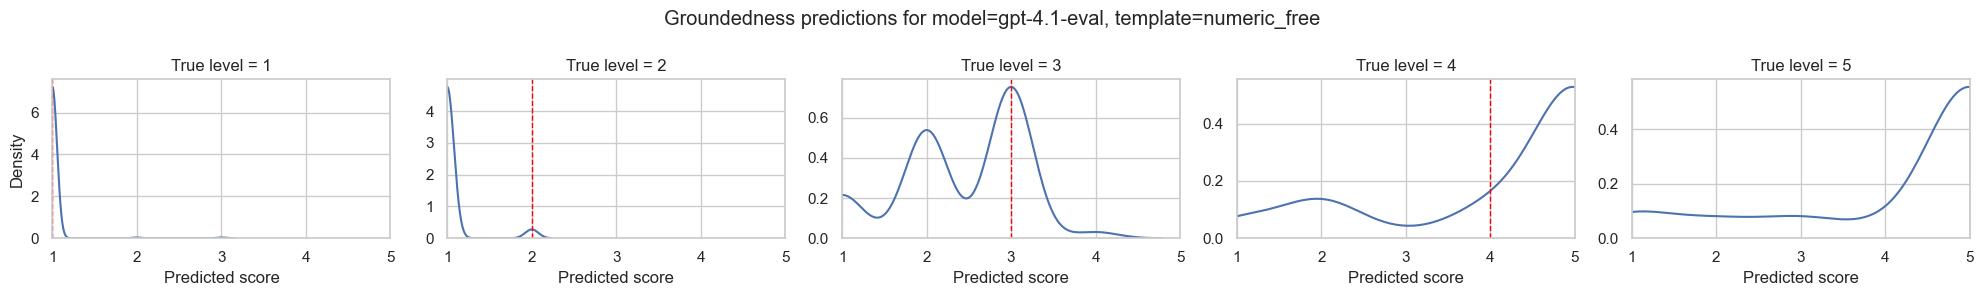

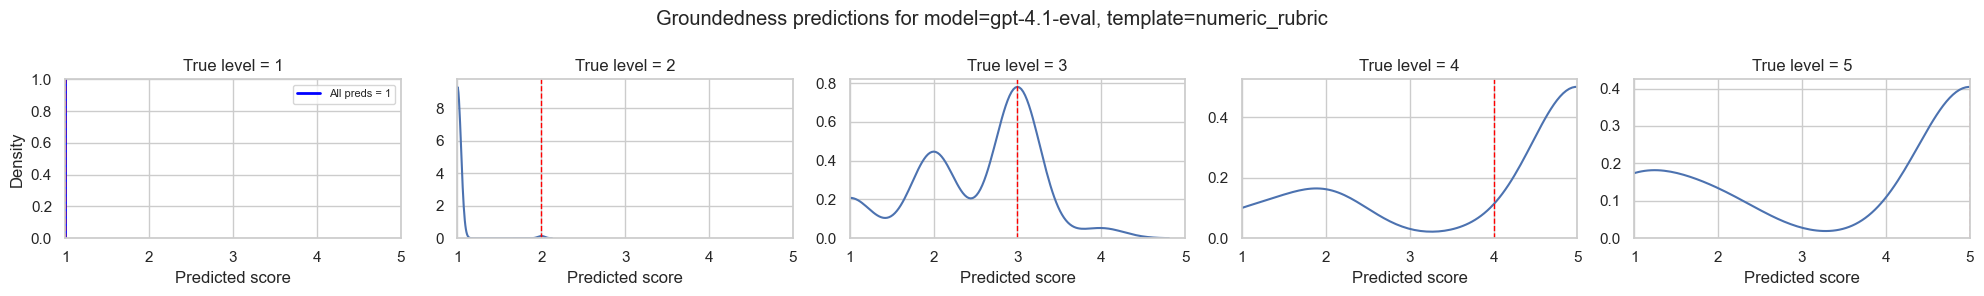

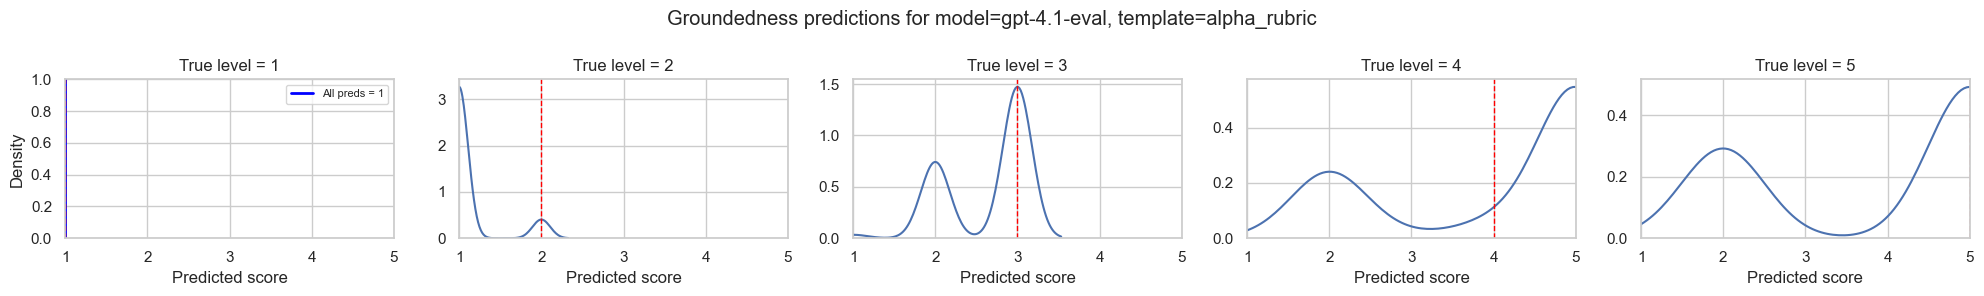

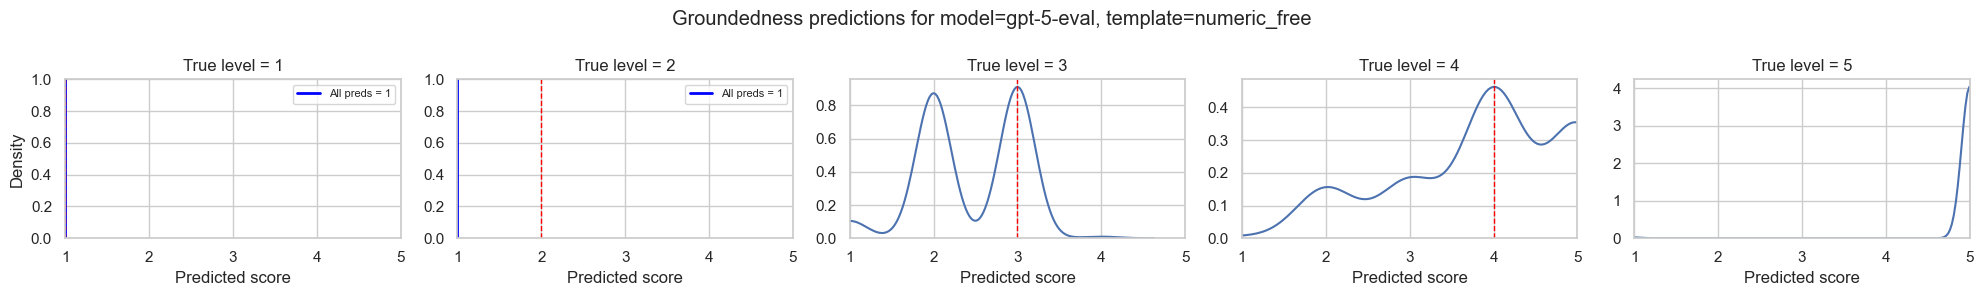

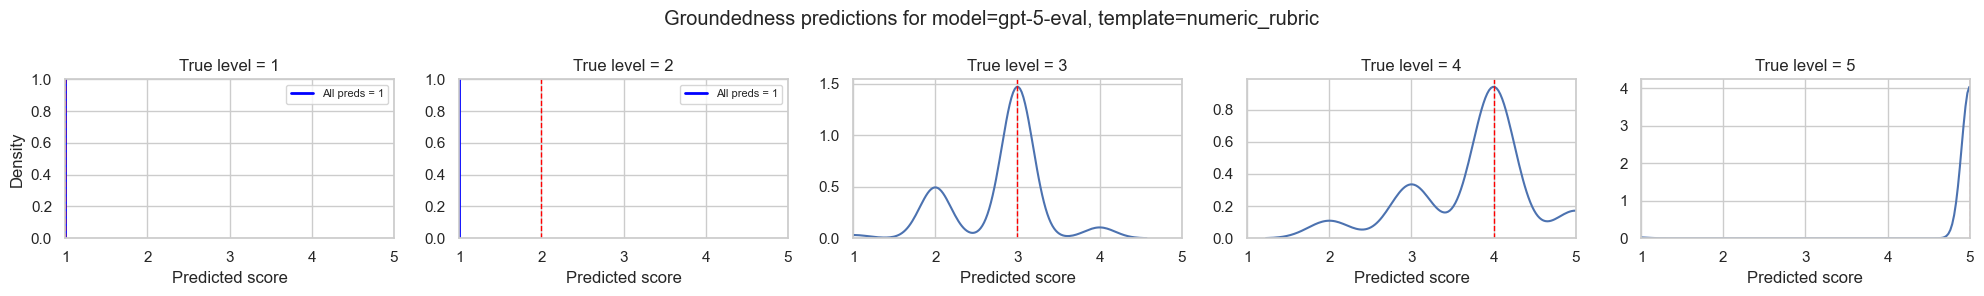

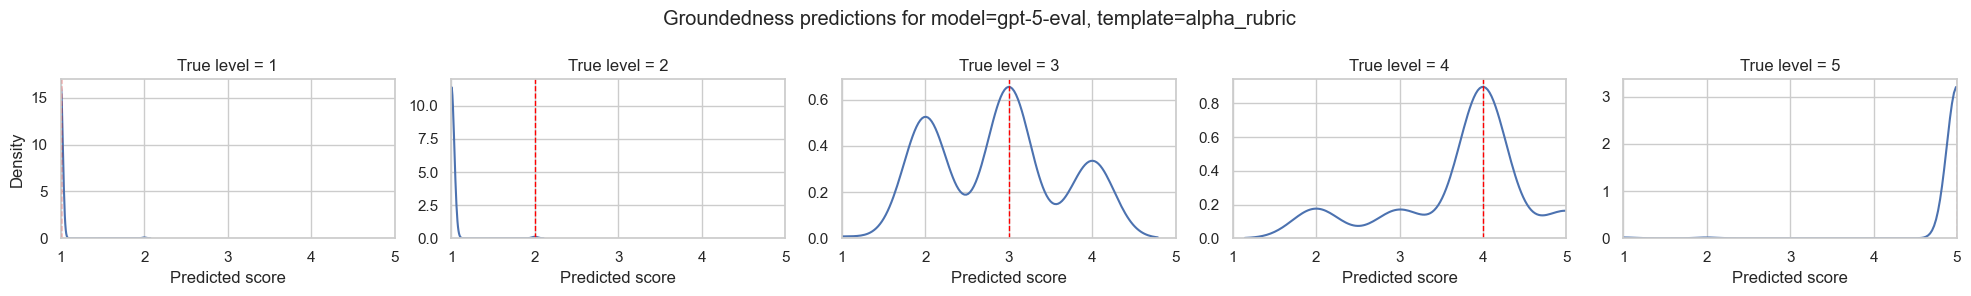

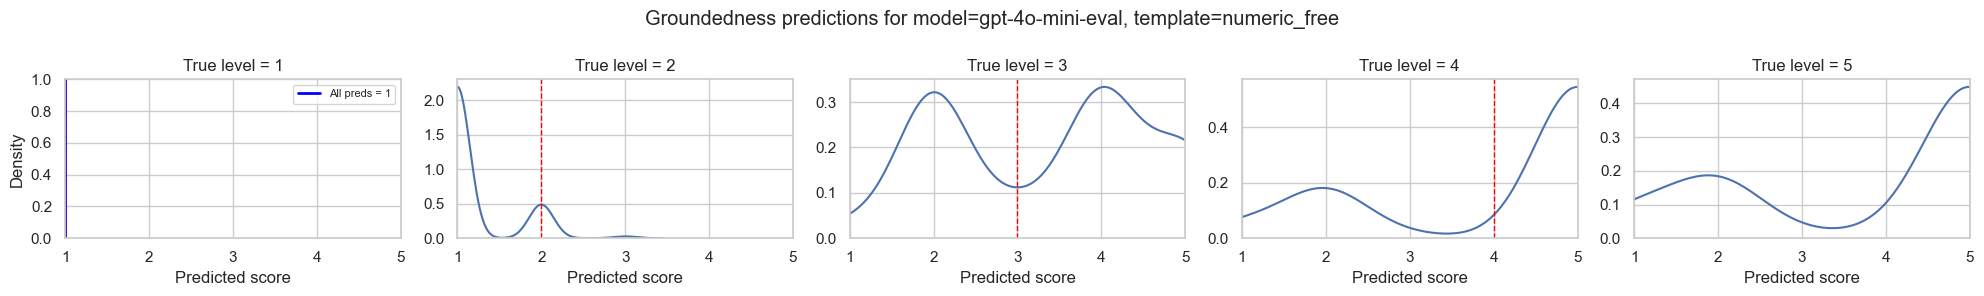

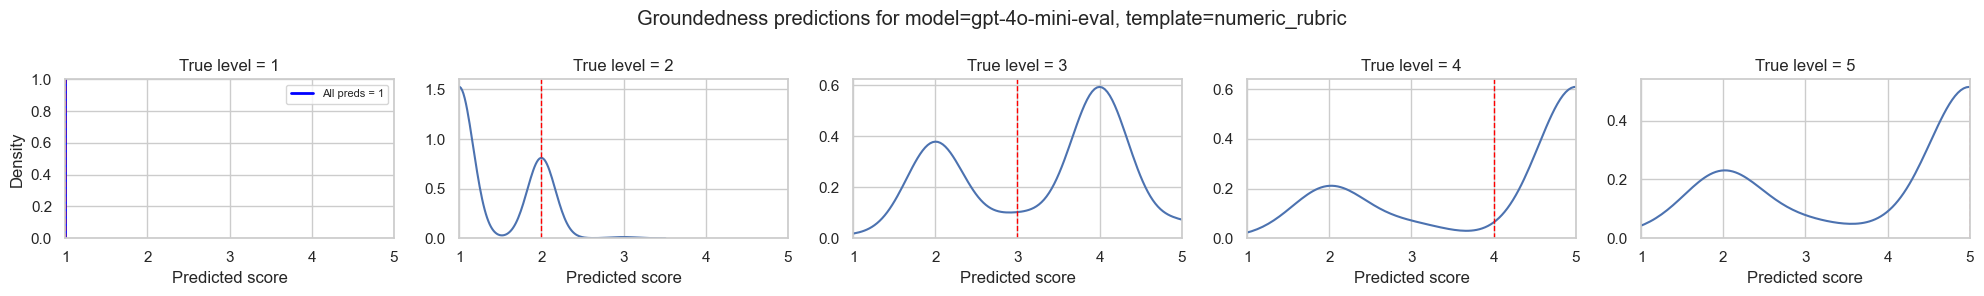

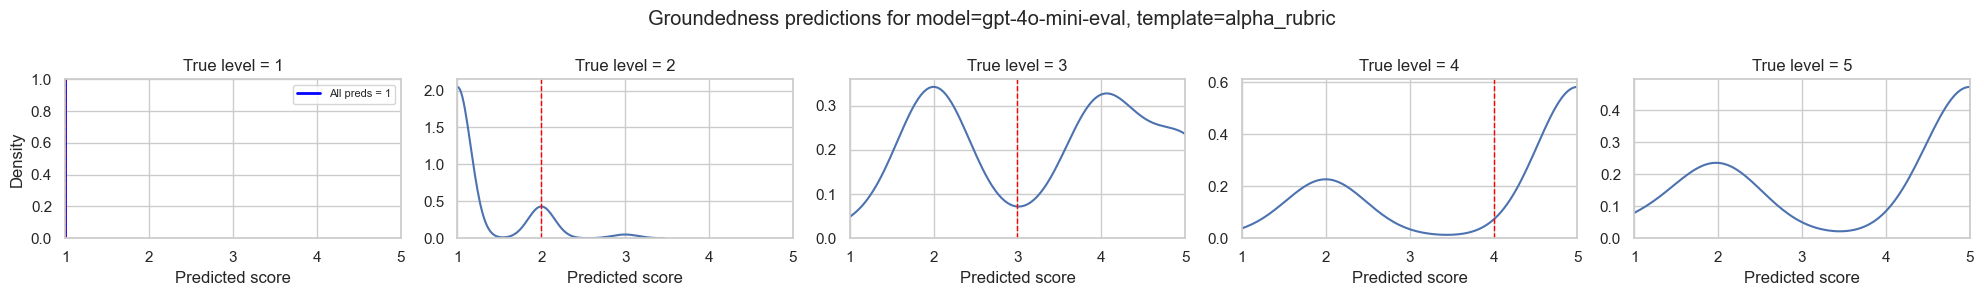

In [22]:
sns.set(style="whitegrid")


def plot_kdes_for_model_template(model_name: str, template_id: str, preds: pd.DataFrame):
    """For a given model and template, plot KDEs over predicted scores for each true groundedness level (1-5)."""
    subset = preds[(preds["model"] == model_name) & (preds["template"] == template_id)]
    fig, axes = plt.subplots(1, 5, figsize=(20, 3), sharey=False)  # Independent y-axes

    for g, ax in zip(range(1, 6), axes):
        data_g = subset[subset["ground_truth_score"] == g]["pred_score"].dropna()
        if len(data_g) > 1:
            # Check if data has variance
            if data_g.std() > 0:
                sns.kdeplot(data_g, ax=ax, warn_singular=False)
            else:
                # Zero variance: all predictions are the same value - plot a vertical line
                unique_val = data_g.iloc[0]
                ax.axvline(unique_val, color="blue", linewidth=2, label=f"All preds = {unique_val:.0f}")
                ax.legend(fontsize=8)
        else:
            ax.hist(data_g, bins=np.linspace(0.5, 5.5, 6), density=True)

        ax.axvline(g, linestyle="--", linewidth=1, color="red", label="True" if g == 1 else None)
        ax.set_title(f"True level = {g}")
        ax.set_xlim(1, 5)
        ax.set_xlabel("Predicted score")
        ax.set_ylabel("Density" if g == 1 else "")

    fig.suptitle(f"Groundedness predictions for model={model_name}, template={template_id}")
    plt.tight_layout()
    plt.show()


for model in MODEL_DEPLOYMENTS:
    for template_id in ["numeric_free", "numeric_rubric", "alpha_rubric"]:
        plot_kdes_for_model_template(model["name"], template_id, preds_df)

In [ ]:
# =============================================================================
# Run Azure AI SDK GroundednessEvaluator (single run, for comparison)
# =============================================================================
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

model_config = {
    "azure_endpoint": AZURE_AI_PROJECT_URL,
    "azure_deployment": MODEL_DEPLOYMENTS[0]["deployment"],
}

groundedness_eval = GroundednessEvaluator(model_config=model_config, credential=credential)

SDK_BATCH_SIZE = 10


def evaluate_single_row(row_dict):
    """Evaluate a single row with the SDK evaluator."""
    try:
        result = groundedness_eval(
            response=row_dict["answer"],
            context=row_dict["context"],
            query=row_dict["question"],
        )
        return float(result["groundedness"])
    except Exception as e:
        print(f"Error evaluating row {row_dict.get('id', 'unknown')}: {e}")
        return np.nan


# Run evaluations in parallel batches
sdk_scores = [None] * len(df)
rows_as_dicts = df.to_dict("records")

with ThreadPoolExecutor(max_workers=SDK_BATCH_SIZE) as executor:
    pbar = tqdm(total=len(rows_as_dicts), desc="SDK Groundedness Evaluation")
    
    for i in range(0, len(rows_as_dicts), SDK_BATCH_SIZE):
        batch = rows_as_dicts[i:i + SDK_BATCH_SIZE]
        batch_indices = list(range(i, min(i + SDK_BATCH_SIZE, len(rows_as_dicts))))
        futures = [executor.submit(evaluate_single_row, row) for row in batch]
        
        for idx, future in zip(batch_indices, futures):
            sdk_scores[idx] = future.result()
        
        pbar.update(len(batch))
    pbar.close()

df["pred_sdk_groundedness"] = sdk_scores
print(f"SDK evaluation complete. {sum(1 for s in sdk_scores if not np.isnan(s))} successful evaluations.")

SDK Groundedness Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]

In [29]:
# =============================================================================
# FINAL COMPARISON MATRIX: All methods with ordinal metrics (MAE, exact match, etc.)
# =============================================================================

def ordinal_metrics(y_true, y_pred):
    """
    Compute ordinal/regression-style metrics for 1-5 groundedness scores.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    
    # Remove NaN pairs
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    
    if len(y_true) == 0:
        return {k: np.nan for k in ["mae", "rmse", "exact_match", "within_1", "pearson", "spearman", "n"]}
    
    mae = np.abs(y_true - y_pred).mean()
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    exact = (y_true == y_pred).mean()
    within_1 = (np.abs(y_true - y_pred) <= 1).mean()
    pearson = pearsonr(y_true, y_pred)[0] if len(y_true) > 1 else np.nan
    spearman = spearmanr(y_true, y_pred)[0] if len(y_true) > 1 else np.nan
    
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "exact_match": float(exact),
        "within_1": float(within_1),
        "pearson": float(pearson),
        "spearman": float(spearman),
        "n": int(len(y_true)),
    }


# Build final results for all model/template combinations (averaging across runs)
final_results = []

for (model_name, template_id), group in preds_df.groupby(["model", "template"]):
    metrics = ordinal_metrics(group["ground_truth_score"], group["pred_score"])
    metrics["model"] = model_name
    metrics["template"] = template_id
    final_results.append(metrics)

# Add SDK evaluator results
sdk_metrics = ordinal_metrics(df["ground_truth_score"], df["pred_sdk_groundedness"])
sdk_metrics["model"] = "AzureAI_SDK"
sdk_metrics["template"] = "built_in"
final_results.append(sdk_metrics)

# Create final comparison dataframe
final_df = pd.DataFrame(final_results)

# Pivot to show models as rows and metrics as a clean table
pivot_cols = ["mae", "rmse", "exact_match", "within_1", "pearson", "spearman", "n"]
final_df["method"] = final_df["model"] + " / " + final_df["template"]

# Sort by MAE (lower is better)
final_df_sorted = final_df.sort_values("mae")

print("=" * 80)
print("FINAL PERFORMANCE COMPARISON (sorted by MAE, lower is better)")
print("=" * 80)
display(final_df_sorted[["method", "mae", "rmse", "exact_match", "within_1", "pearson", "spearman", "n"]].reset_index(drop=True))

# Summary by model only (aggregate across templates)
print("\n" + "=" * 80)
print("SUMMARY BY MODEL (averaged across templates)")
print("=" * 80)
model_summary = (
    final_df[final_df["template"] != "built_in"]  # exclude SDK for fair comparison
    .groupby("model")[["mae", "rmse", "exact_match", "within_1", "pearson", "spearman"]]
    .mean()
    .sort_values("mae")
)
display(model_summary)

# Summary by template only (aggregate across models)
print("\n" + "=" * 80)
print("SUMMARY BY TEMPLATE (averaged across models)")
print("=" * 80)
template_summary = (
    final_df[final_df["template"] != "built_in"]
    .groupby("template")[["mae", "rmse", "exact_match", "within_1", "pearson", "spearman"]]
    .mean()
    .sort_values("mae")
)
display(template_summary)

,method,mae,rmse,exact_match,within_1,pearson,spearman,n
0,gpt-5-eval / numeric_rubric,0.360000,0.637181,0.660000,0.982000,0.938976,0.945445,1000
1,gpt-5-eval / alpha_rubric,0.418418,0.698920,0.612613,0.971972,0.921938,0.936534,999
2,gpt-5-eval / numeric_free,0.468000,0.749667,0.575000,0.960000,0.919213,0.933856,1000
3,gpt-4.1-eval / alpha_rubric,0.721000,1.140614,0.491000,0.865000,0.767833,0.820882,1000
4,gpt-4.1-eval / numeric_free,0.734000,1.154123,0.469000,0.871000,0.779502,0.797910,1000
5,gpt-4o-mini-eval / numeric_rubric,0.785000,1.143241,0.409000,0.869000,0.745935,0.801322,1000
6,gpt-4.1-eval / numeric_rubric,0.864000,1.358676,0.440000,0.837000,0.696290,0.719578,1000
7,gpt-4o-mini-eval / alpha_rubric,0.903000,1.277106,0.365000,0.817000,0.703273,0.773910,1000
8,gpt-4o-mini-eval / numeric_free,0.908000,1.315295,0.375000,0.822000,0.689067,0.740922,1000
9,AzureAI_SDK / built_in,0.960000,1.532971,0.455000,0.790000,0.605683,0.535377,200


,mae,rmse,exact_match,within_1,pearson,spearman
model,,,,,,
gpt-5-eval,0.415473,0.695256,0.615871,0.971324,0.926709,0.938611
gpt-4.1-eval,0.773000,1.217804,0.466667,0.857667,0.747875,0.779457
gpt-4o-mini-eval,0.865333,1.245214,0.383000,0.836000,0.712759,0.772051


,mae,rmse,exact_match,within_1,pearson,spearman
template,,,,,,
numeric_rubric,0.669667,1.046366,0.503000,0.896000,0.793734,0.822115
alpha_rubric,0.680806,1.038880,0.489538,0.884657,0.797681,0.843776
numeric_free,0.703333,1.073028,0.473000,0.884333,0.795927,0.824229
